# Импорты

In [ ]:
pip install pymorphy3 catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 989.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 35.1 MB/s eta 0:00:00


In [ ]:
!python -m spacy download ru_core_news_lg

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 513.4/513.4 MB 2.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import re
import numpy as np
import pandas as pd
from collections import Counter
import spacy
import pymorphy3
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import train_test_split, KFold

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score

from tqdm.auto import tqdm
from sklearn.base import clone

from contextlib import contextmanager
import joblib
from joblib import parallel

from catboost import CatBoostRegressor

import torch
from transformers import pipeline
from tqdm.auto import tqdm

from sklearn.metrics import r2_score
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Загрузка данных

In [ ]:
FILES = [
    "/content/aggregated_results_by_ds__pool_37806285__2023_02_18.tsv",
    "/content/aggregated_results_by_ds__pool_37939772__2023_02_27.tsv",
]

In [ ]:
def parse_category(x):
    """
    Превращает строку вида "[4]" -> 4
    (иногда может быть пробел/другой формат, поэтому используем regex).
    """
    if pd.isna(x):
        return np.nan
    m = re.search(r"-?\d+", str(x))
    return int(m.group()) if m else np.nan

In [ ]:
def parse_confidence(x):
    """ "100.00%" -> 100.0 """
    if pd.isna(x):
        return np.nan
    return float(str(x).replace("%", "").strip())

In [ ]:
def load_one(path: str) -> pd.DataFrame:
    df = pd.read_csv(path, sep="\t")
    df = df.rename(columns={
        "INPUT:text": "text",
        "OUTPUT:category": "category_raw",
        "CONFIDENCE:category": "confidence_raw",
    })

    df["complexity"] = df["category_raw"].apply(parse_category)
    df["confidence"] = df["confidence_raw"].apply(parse_confidence)

    # чистка
    df = df.dropna(subset=["text", "complexity"]).copy()
    df["complexity"] = df["complexity"].astype(int)

    return df[["text", "complexity", "confidence"]]

In [ ]:
#читаем оба файла
dfs = [load_one(p) for p in FILES]

In [ ]:
#собираем в единый датасет
data = pd.concat(dfs, ignore_index=True)

In [ ]:
data

,text,complexity,confidence
0,"Разглядывая их под микроскопом , мы увидим при...",4,100.0
1,"Иногда талантливые люди , не найдя себя в наук...",4,100.0
2,Кандидаты в депутаты от общественных организац...,6,100.0
3,"Главное , чтобы "" социальные лифты "" не остана...",6,100.0
4,Франция признает российских студентов и не при...,2,100.0
...,...,...,...
1195,В 1991 - 2008 чемпионками мира ( с перерывами ...,3,100.0
1196,То есть сейчас действительно уже можно получат...,5,100.0
1197,"Да и понятия "" параолимпийский тренер "" в обыд...",7,100.0
1198,Такое представление на длительное время заторм...,5,100.0


In [ ]:
# статистика по датасету
print("Кол-во строк:", len(data))
print("Кол-во уникальных текстов:", data["text"].nunique())

Кол-во строк: 1200
Кол-во уникальных текстов: 1200


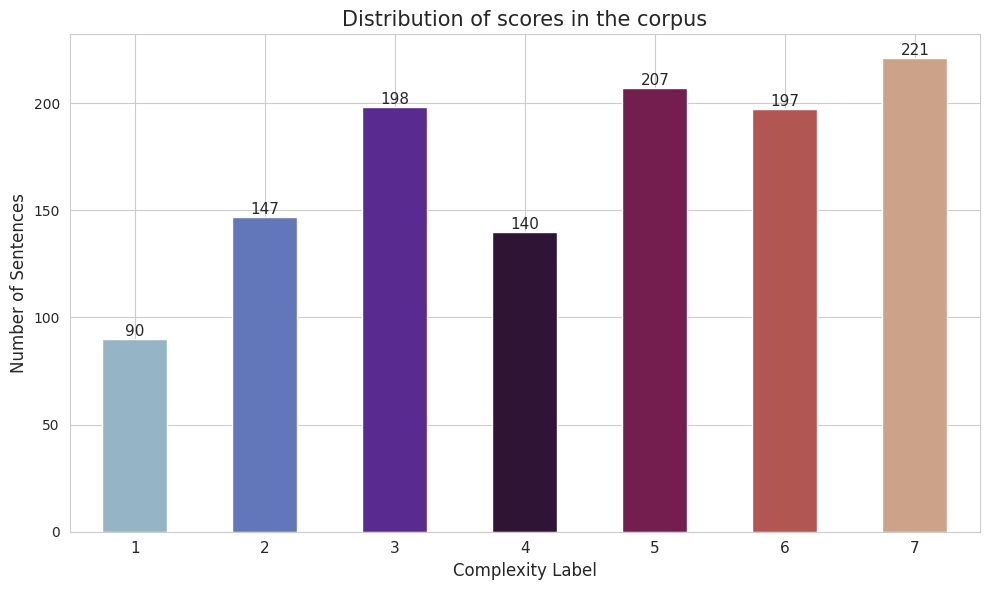

In [ ]:
counts = data["complexity"].value_counts().sort_index()

sns.set_style("whitegrid")

ax = counts.plot(kind="bar", figsize=(10, 6), color=sns.color_palette("twilight", len(counts)))
ax.set_xlabel("Complexity Label", fontsize=12)
ax.set_ylabel("Number of Sentences", fontsize=12)
ax.set_title("Distribution of scores in the corpus", fontsize=15)
ax.bar_label(ax.containers[0], fontsize=11)

plt.xticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
data[["complexity","confidence"]].describe()

,complexity,confidence
count,1200.000000,1200.000000
mean,4.418333,99.967792
std,1.909110,0.934101
min,1.000000,68.310000
25%,3.000000,100.000000
50%,5.000000,100.000000
75%,6.000000,100.000000
max,7.000000,100.000000


# Выделение признаков

In [ ]:
morph = pymorphy3.MorphAnalyzer()

In [ ]:
nlp = spacy.load("ru_core_news_lg")

In [ ]:
# --- РУССКИЕ СЛОВАРИ (базовые) ---
ACADEMIC_WORDS_RU = {
    'анализ', 'метод', 'система', 'процесс', 'результат', 'исследование',
    'развитие', 'влияние', 'взаимодействие', 'факт', 'явление', 'функция',
    'механизм', 'структура', 'форма', 'содержание', 'противоречие', 'связь'
}

TECHNICAL_TERMS_RU = {
    'алгоритм', 'модель', 'параметр', 'функция', 'переменная', 'операция',
    'компонент', 'элемент', 'система', 'интеграция', 'оптимизация', 'протокол'
}

# Психолингвистические словари (если есть, иначе базовые)
CONCRETENESS_DICT = {
    'дом': 4.5, 'стол': 4.8, 'книга': 4.2, 'мысль': 1.5, 'идея': 1.3,
    'время': 2.1, 'число': 2.8, 'цвет': 3.5, 'звук': 4.0, 'вода': 4.6,
}

AOA_DICT = {
    'мама': 2, 'папа': 2, 'дом': 3, 'кот': 3, 'собака': 3, 'книга': 4,
    'школа': 4, 'работа': 5, 'анализ': 8, 'теория': 9, 'концепция': 10,
}

FREQUENCY_DICT_SAMPLE = {
    'и': 9.5, 'в': 9.3, 'на': 9.2, 'что': 9.0, 'он': 8.8, 'она': 8.7,
    'это': 8.6, 'быть': 8.5, 'как': 8.4, 'мир': 7.0, 'человек': 7.2,
    'анализ': 5.5, 'интеграция': 4.2, 'оптимизация': 3.8,
}

In [ ]:
def tokenize_sentences(text):
    """Разбить текст на предложения."""
    sentences = re.split(r'[.!?]+', text)
    return [s.strip() for s in sentences if s.strip()]


def tokenize_words(text):
    """Разбить текст на слова."""
    words = re.findall(r'\b[\wа-яА-ЯёЁ-]+\b', text.lower())
    return words


def get_lemmas(words):
    """Получить леммы для слов."""
    lemmas = []
    for word in words:
        parsed = morph.parse(word)[0]
        lemmas.append(parsed.normal_form)
    return lemmas

def get_pos_tags(words):
    """Получить части речи (pymorphy)."""
    pos_tags = []
    for word in words:
        parsed = morph.parse(word)[0]
        pos_tags.append(parsed.tag.POS)
    return pos_tags

In [ ]:
# СИНТАКСИЧЕСКИЕ ПРИЗНАКИ

def extract_syntactic_features(text):
    """Извлечь 37 синтаксических признаков."""
    features = {}
    sentences = tokenize_sentences(text)
    words = tokenize_words(text)
    pos_tags = get_pos_tags(words)

    # Длина и структура
    sentence_lengths = [len(tokenize_words(s)) for s in sentences if s]
    if sentence_lengths:
        features['sentence_length_avg'] = np.mean(sentence_lengths)
        features['sentence_length_std'] = np.std(sentence_lengths)
        features['sentence_length_max'] = np.max(sentence_lengths)
        features['sentence_length_min'] = np.min(sentence_lengths)
    else:
        features['sentence_length_avg'] = 0
        features['sentence_length_std'] = 0
        features['sentence_length_max'] = 0
        features['sentence_length_min'] = 0

    # Части речи
    pos_counter = Counter(pos_tags)
    total_pos = len(pos_tags) if pos_tags else 1

    features['verb_ratio'] = pos_counter.get('VERB', 0) / total_pos
    features['noun_ratio'] = pos_counter.get('NOUN', 0) / total_pos
    features['adjective_ratio'] = pos_counter.get('ADJF', 0) / total_pos
    features['adverb_ratio'] = pos_counter.get('ADVB', 0) / total_pos
    features['pronoun_ratio'] = pos_counter.get('PRON', 0) / total_pos
    features['preposition_ratio'] = pos_counter.get('PREP', 0) / total_pos
    features['conjunction_ratio'] = pos_counter.get('CONJ', 0) / total_pos

    # Модальные глаголы
    modal_verbs = {'может', 'можно', 'должен', 'надо', 'нужно', 'следует'}
    features['modal_verb_ratio'] = sum(1 for w in words if w in modal_verbs) / total_pos

    # Пассивный залог (примерная оценка по суффиксам)
    features['passive_voice_ratio'] = sum(1 for w in words if w.endswith('ся')) / total_pos

    # Причастия и деепричастия
    features['participle_count'] = sum(1 for tag in pos_tags if tag == 'PRTF') / len(sentences) if sentences else 0
    features['gerund_count'] = sum(1 for tag in pos_tags if tag == 'GRND') / len(sentences) if sentences else 0

    # Сложность: количество придаточных (примерно по союзам)
    subordinate_conj = {'что', 'который', 'чтобы', 'если', 'так как', 'потому что'}
    features['subordination_ratio'] = sum(1 for w in words if w in subordinate_conj) / max(1, len(sentences))

    # Вложенность (примерная: по скобкам и запятым)
    features['embedding_depth'] = text.count('(') + text.count('[')
    features['punctuation_density'] = len(re.findall(r'[,;:—–-]', text)) / max(1, len(words))

    # Предложные фразы
    features['prepositional_phrase_count'] = len([w for w in words if w in {'в', 'на', 'с', 'по', 'из', 'у', 'для', 'о', 'об', 'от', 'к'}]) / max(1, len(sentences))

    # Дополнительные признаки
    features['complex_sentences_ratio'] = sum(1 for s in sentences if len(tokenize_words(s)) > 15) / max(1, len(sentences))
    features['simple_sentences_ratio'] = sum(1 for s in sentences if len(tokenize_words(s)) <= 5) / max(1, len(sentences))
    features['ellipsis_count'] = text.count('...')
    features['parenthesis_count'] = text.count('(') + text.count(')')
    features['quotation_density'] = text.count('"') / max(1, len(words))

    # Информационная плотность
    noun_verb_count = pos_counter.get('NOUN', 0) + pos_counter.get('VERB', 0)
    features['noun_density'] = noun_verb_count / max(1, len(words))

    # Функциональные слова
    func_words = {'и', 'в', 'на', 'что', 'как', 'то', 'это', 'если', 'так'}
    features['function_word_ratio'] = sum(1 for w in words if w in func_words) / max(1, len(words))
    features['content_word_ratio'] = 1 - features['function_word_ratio']

    return features

In [ ]:
# ЛЕКСИЧЕСКИЕ ПРИЗНАКИ

def extract_lexical_features(text):
    """Извлечь 48 лексических признаков."""
    features = {}
    words = tokenize_words(text)
    lemmas = get_lemmas(words)

    if not words:
        return {f: 0 for f in ['TTR', 'lemma_TTR', 'word_length_avg', 'word_length_std',
                               'rare_words_percentage', 'academic_words_ratio', 'technical_terms_ratio',
                               'unique_words_ratio', 'long_words_ratio', 'high_frequency_words_ratio']}

    # TTR и разнообразие
    unique_words = len(set(words))
    unique_lemmas = len(set(lemmas))
    features['TTR'] = unique_words / len(words)
    features['lemma_TTR'] = unique_lemmas / len(lemmas) if lemmas else 0
    features['MSTTR'] = features['TTR'] * (1 - features['TTR'] / len(words))  # Modified TTR

    # Уникальные слова
    word_freq = Counter(words)
    features['unique_words_ratio'] = sum(1 for count in word_freq.values() if count == 1) / len(words)
    features['high_frequency_words_ratio'] = sum(1 for w in words if word_freq[w] > 2) / len(words)

    # Длина слов
    word_lengths = [len(w) for w in words]
    features['word_length_avg'] = np.mean(word_lengths)
    features['word_length_std'] = np.std(word_lengths)
    features['long_words_ratio'] = sum(1 for w in words if len(w) > 6) / len(words)

    # Сложность лексики
    features['academic_words_ratio'] = sum(1 for w in lemmas if w in ACADEMIC_WORDS_RU) / len(words)
    features['technical_terms_ratio'] = sum(1 for w in lemmas if w in TECHNICAL_TERMS_RU) / len(words)

    # Частотность
    avg_freq = np.mean([FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in words])
    features['word_frequency_mean'] = avg_freq
    features['word_frequency_std'] = np.std([FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in words])

    # Редкие слова (частотность < 5.0)
    features['rare_words_percentage'] = sum(1 for w in words if FREQUENCY_DICT_SAMPLE.get(w, 5.0) < 5.0) / len(words)

    # Полисемия (примерно)
    features['polysemy_avg'] = np.mean([len(morph.parse(w)) for w in words])

    # Повторяемость
    max_freq = max(word_freq.values()) if word_freq else 1
    features['repeat_ratio'] = max_freq / len(words)

    # Однокоренные слова
    root_patterns = Counter()
    for w in words:
        root = morph.parse(w)[0].normal_form
        root_patterns[root[:3]] += 1  # Первые 3 буквы как приблизительный корень
    features['cognate_density'] = max(root_patterns.values()) / len(words) if root_patterns else 0

    # Синонимия (примерно: повторение лемм)
    lemma_freq = Counter(lemmas)
    features['synonym_density'] = sum(1 for count in lemma_freq.values() if count > 1) / len(lemmas) if lemmas else 0

    # Лексическая связность (перекрытие соседних предложений)
    sentences = tokenize_sentences(text)
    if len(sentences) > 1:
        overlaps = []
        for i in range(len(sentences) - 1):
            words1 = set(tokenize_words(sentences[i]))
            words2 = set(tokenize_words(sentences[i + 1]))
            if words1 or words2:
                overlaps.append(len(words1 & words2) / max(len(words1), len(words2)))
        features['lexical_cohesion'] = np.mean(overlaps) if overlaps else 0
    else:
        features['lexical_cohesion'] = 0

    return features

In [ ]:
# ПСИХОЛИНГВИСТИЧЕСКИЕ ПРИЗНАКИ

def extract_psycholinguistic_features(text):
    """Извлечь 25 психолингвистических признаков."""
    features = {}
    words = tokenize_words(text)
    lemmas = get_lemmas(words)

    if not words:
        return {f: 0 for f in ['AoA_mean', 'AoA_std', 'concreteness_mean', 'concreteness_std',
                               'predictability_mean', 'surprisal_mean']}

    # Age of Acquisition (AoA)
    aoa_values = [AOA_DICT.get(w, 6.0) for w in lemmas]
    features['AoA_mean'] = np.mean(aoa_values)
    features['AoA_std'] = np.std(aoa_values)
    features['early_acquired_ratio'] = sum(1 for v in aoa_values if v < 5) / len(aoa_values)
    features['late_acquired_ratio'] = sum(1 for v in aoa_values if v > 8) / len(aoa_values)

    # Concreteness (конкретность)
    concreteness_values = [CONCRETENESS_DICT.get(w, 2.5) for w in lemmas]
    features['concreteness_mean'] = np.mean(concreteness_values)
    features['concreteness_std'] = np.std(concreteness_values)
    features['abstract_word_ratio'] = sum(1 for v in concreteness_values if v < 2.5) / len(concreteness_values)
    features['concrete_word_ratio'] = sum(1 for v in concreteness_values if v > 3.5) / len(concreteness_values)

    # Предсказуемость (surprisal) — оценка по частотности
    freq_values = [FREQUENCY_DICT_SAMPLE.get(w, 5.0) for w in lemmas]
    features['word_frequency_mean_lex'] = np.mean(freq_values)
    features['predictability_mean'] = np.mean([1 / (1 + np.exp(-f)) for f in freq_values])  # Sigmoid

    # Surprisal как -log(p) частотности
    surprisal_values = [-np.log(max(0.001, f / 10.0)) for f in freq_values]  # Нормировка
    features['surprisal_mean'] = np.mean(surprisal_values)
    features['surprisal_std'] = np.std(surprisal_values)
    features['surprisal_max'] = max(surprisal_values) if surprisal_values else 0

    # Знакомость (обратное AoA)
    features['familiarity_mean'] = 10 - features['AoA_mean']
    features['familiarity_std'] = features['AoA_std']

    # Эмоциональная валентность (по наличию слов)
    positive_words = {'хороший', 'красивый', 'отличный', 'замечательный', 'прекрасный'}
    negative_words = {'плохой', 'ужасный', 'страшный', 'ненавидеть', 'жалко'}
    features['emotional_valence'] = (sum(1 for w in lemmas if w in positive_words) -
                                      sum(1 for w in lemmas if w in negative_words)) / max(1, len(lemmas))

    # Информационность (content words vs function words)
    features['information_density'] = sum(1 for w in lemmas if len(w) > 4) / len(lemmas)

    return features

In [ ]:
# СЕМАНТИЧЕСКИЕ ПРИЗНАКИ

def extract_semantic_features(text):
    """Извлечь 20 семантических признаков."""
    features = {}
    words = tokenize_words(text)
    sentences = tokenize_sentences(text)

    if not words:
        return {f: 0 for f in ['entity_density', 'semantic_coherence', 'topic_coherence']}

    # Плотность сущностей (примерно: по POS)
    pos_tags = get_pos_tags(words)
    noun_count = sum(1 for tag in pos_tags if tag == 'NOUN')
    features['entity_density'] = noun_count / len(words)

    # Перекрытие сущностей между предложениями
    if len(sentences) > 1:
        overlaps = []
        for i in range(len(sentences) - 1):
            nouns1 = set(w for w, tag in zip(tokenize_words(sentences[i]),
                                              get_pos_tags(tokenize_words(sentences[i])))
                        if tag == 'NOUN')
            nouns2 = set(w for w, tag in zip(tokenize_words(sentences[i + 1]),
                                              get_pos_tags(tokenize_words(sentences[i + 1])))
                        if tag == 'NOUN')
            if nouns1 or nouns2:
                overlaps.append(len(nouns1 & nouns2) / max(len(nouns1), len(nouns2)))
        features['entity_overlap'] = np.mean(overlaps) if overlaps else 0
    else:
        features['entity_overlap'] = 0

    # Кореферентность (примерно: местоимения)
    pronouns = {'он', 'она', 'оно', 'они', 'это', 'тот', 'этот'}
    features['pronoun_antecedent_distance'] = np.mean([min(i, len(words) - i)
                                                        for i, w in enumerate(words) if w in pronouns]) if any(w in pronouns for w in words) else 0

    # Причинно-следственные отношения
    causal_markers = {'потому', 'поэтому', 'следовательно', 'так как', 'вследствие'}
    features['causal_relation_density'] = sum(1 for w in words if w in causal_markers) / max(1, len(sentences))

    # Временные ссылки
    temporal_markers = {'когда', 'после', 'перед', 'затем', 'потом', 'раньше', 'позже'}
    features['temporal_reference_count'] = sum(1 for w in words if w in temporal_markers) / max(1, len(sentences))

    # Пространственные ссылки
    spatial_markers = {'где', 'здесь', 'там', 'рядом', 'близко', 'далеко', 'перед', 'позади'}
    features['spatial_reference_count'] = sum(1 for w in words if w in spatial_markers) / max(1, len(sentences))

    # Отрицания
    negation_words = {'не', 'нет', 'никто', 'ничто', 'никакой'}
    features['negation_ratio'] = sum(1 for w in words if w in negation_words) / len(words)
    features['negation_scope'] = np.mean([len(w) for w in words if w in negation_words]) if any(w in negation_words for w in words) else 0

    # Семантическая когерентность (по лексическому перекрытию)
    if len(sentences) > 1:
        coherences = []
        for i in range(len(sentences) - 1):
            words1 = set(tokenize_words(sentences[i]))
            words2 = set(tokenize_words(sentences[i + 1]))
            if words1 or words2:
                coherences.append(len(words1 & words2) / max(len(words1), len(words2)))
        features['semantic_coherence'] = np.mean(coherences) if coherences else 0
    else:
        features['semantic_coherence'] = 0

    # Тематическая связность (разнообразие слов)
    unique_words = len(set(words))
    features['topic_coherence'] = 1 - (unique_words / len(words)) if words else 0

    # Реферативная связность (лексическое чейнинг)
    word_freq = Counter(words)
    features['referential_cohesion'] = sum(1 for count in word_freq.values() if count > 1) / len(word_freq)

    # Информационная плотность
    content_words = sum(1 for w in words if len(w) > 4)
    features['information_density'] = content_words / len(words)

    return features

In [ ]:
# МОРФОЛОГИЧЕСКИЕ ПРИЗНАКИ

def extract_morphological_features(text):
    """Извлечь 10 морфологических признаков."""
    features = {}
    words = tokenize_words(text)

    if not words:
        return {f: 0 for f in ['case_variety', 'tense_variety', 'mood_variety', 'aspect_variety']}

    # Разнообразие морфологических форм
    morph_forms = Counter()
    cases = Counter()
    tenses = Counter()
    moods = Counter()
    aspects = Counter()

    for word in words:
        parsed = morph.parse(word)[0]
        tag = parsed.tag

        morph_forms[str(tag)] += 1

        if tag.case:
            cases[tag.case] += 1
        if tag.tense:
            tenses[tag.tense] += 1
        if tag.mood:
            moods[tag.mood] += 1
        if tag.aspect:
            aspects[tag.aspect] += 1

    # Разнообразие
    features['morphological_diversity'] = len(morph_forms) / len(words)
    features['case_variety'] = len(cases) / max(1, sum(cases.values()))
    features['tense_variety'] = len(tenses) / max(1, sum(tenses.values()))
    features['mood_variety'] = len(moods) / max(1, sum(moods.values()))
    features['aspect_variety'] = len(aspects) / max(1, sum(aspects.values()))

    # Префиксы и суффиксы
    prefix_count = sum(1 for w in words if w.startswith(('не', 'при', 'пре', 'про', 'раз', 'без')))
    suffix_count = sum(1 for w in words if w.endswith(('ся', 'ал', 'ение', 'ость', 'ость')))
    features['prefix_count'] = prefix_count / len(words)
    features['suffix_count'] = suffix_count / len(words)
    features['inflection_complexity'] = len(morph_forms) / len(words)

    return features

In [ ]:
# КОМБИНИРОВАННЫЕ ПРИЗНАКИ

def extract_combined_features(syntactic, lexical, psycholing):
    """Извлечь 5 комбинированных признаков."""
    features = {}

    features['syntactic_lex_interaction'] = (syntactic.get('sentence_length_avg', 1) *
                                             lexical.get('TTR', 0.5))
    features['surprisal_word_length_interaction'] = (psycholing.get('surprisal_mean', 0) *
                                                      lexical.get('word_length_avg', 1))
    features['frequency_concreteness_interaction'] = (lexical.get('word_frequency_mean', 5) *
                                                       psycholing.get('concreteness_mean', 2.5))
    features['TTR_sentence_length_interaction'] = (lexical.get('TTR', 0.5) *
                                                    syntactic.get('sentence_length_avg', 1))
    features['complexity_combined'] = (syntactic.get('sentence_length_avg', 0) *
                                       lexical.get('word_length_avg', 0) *
                                       psycholing.get('surprisal_mean', 0))

    return features

In [ ]:
SUBORD_LEMMAS = {
    "что", "чтобы", "если", "когда", "поскольку", "потому", "хотя",
    "который", "которая", "которые"
}

CLAUSAL_DEPS = {"ROOT", "ccomp", "xcomp", "advcl", "acl", "relcl", "parataxis"}
NP_HEAD_DEPS = {"nsubj", "obj", "iobj", "obl", "nmod", "appos", "conj"}

def features_from_paper(sent: str) -> dict:
    doc = nlp(sent)

    # sen_len (chars)
    sen_len = len(sent)

    # Avg_token_length — средняя длина токена (букв) без пунктуации
    toks = [t for t in doc if not t.is_punct and not t.is_space]
    avg_token_length = float(np.mean([len(t.text) for t in toks])) if toks else 0.0

    # Prop_* — доли частей речи
    n = len(toks) if toks else 1
    prop_nouns = sum(1 for t in toks if t.pos_ in {"NOUN", "PROPN"}) / n
    prop_verbs = sum(1 for t in toks if t.pos_ in {"VERB", "AUX"}) / n
    prop_adjectives = sum(1 for t in toks if t.pos_ in {"ADJ"}) / n
    prop_pronouns = sum(1 for t in toks if t.pos_ in {"PRON", "DET"}) / n

    # Average_path_length / Maximum_path_length:
    # dependency distance = |i - head_i|
    dists = []
    for t in toks:
        if t.head == t:
            continue
        dists.append(abs(t.i - t.head.i))
    average_path_length = float(np.mean(dists)) if dists else 0.0
    maximum_path_length = int(np.max(dists)) if dists else 0

    # Num_subordinating_conjunctions:
    # 1) pos_ == SCONJ (подчинительные союзы)
    # 2) + некоторые частые леммы (что/чтобы/который...) чтобы покрыть относит. местоимения
    num_subordinating_conjunctions = sum(
        1 for t in toks
        if (t.pos_ == "SCONJ") or (t.lemma_.lower() in SUBORD_LEMMAS)
    )

    # Num_clauses:
    # практичный proxy: количество "клауза-голов" среди VERB/AUX по dependency labels + ROOT
    num_clauses = sum(
        1 for t in toks
        if (t.pos_ in {"VERB", "AUX"}) and (t.dep_ in CLAUSAL_DEPS)
    )
    num_clauses = max(1, num_clauses) if any(t.pos_ in {"VERB", "AUX"} for t in toks) else 0

    # Num_phrases:
    # так как noun_chunks для ru может быть недоступен, считаем число NP-голов (proxy)
    num_phrases = sum(
        1 for t in toks
        if (t.pos_ in {"NOUN", "PROPN", "PRON"}) and (t.dep_ in NP_HEAD_DEPS)
    )

    # Average_freq:
    # сюда позже подключите реальный частотный ресурс (wordfreq / частотный словарь)
    average_freq = np.nan

    return {
        "Average_path_length": average_path_length,
        "Maximum_path_length": maximum_path_length,
        "Num_clauses": int(num_clauses),
        "Num_phrases": int(num_phrases),
        "Num_subordinating_conjunctions": int(num_subordinating_conjunctions),
        "Prop_nouns": float(prop_nouns),
        "Prop_verbs": float(prop_verbs),
        "Prop_adjectives": float(prop_adjectives),
        "Prop_pronouns": float(prop_pronouns),
        "Average_freq": average_freq,
        "Avg_token_length": avg_token_length,
        "sen_len": int(sen_len),
    }

In [ ]:
# ГЛАВНАЯ ФУНКЦИЯ ДЛЯ ВСЕХ ПРИЗНАКОВ

def extract_all_features(text):
    """Извлечь все признаки."""

    syntactic = extract_syntactic_features(text)
    lexical = extract_lexical_features(text)
    psycholing = extract_psycholinguistic_features(text)
    semantic = extract_semantic_features(text)
    morphological = extract_morphological_features(text)
    combined = extract_combined_features(syntactic, lexical, psycholing)
    paper = features_from_paper(text)

    # Объединить все
    all_features = {
        **{f'synt_{k}': v for k, v in syntactic.items()},
        **{f'lex_{k}': v for k, v in lexical.items()},
        **{f'psych_{k}': v for k, v in psycholing.items()},
        **{f'sem_{k}': v for k, v in semantic.items()},
        **{f'morph_{k}': v for k, v in morphological.items()},
        **{f'comb_{k}': v for k, v in combined.items()},
        **{f'paper_{k}': v for k, v in paper.items()},
    }

    return all_features

In [ ]:
if __name__ == "__main__":
    df = data
    print("Извлечение признаков...")

    features_list = []
    for idx, row in df.iterrows():
        if idx % 100 == 0:
            print(f"Обработано {idx} предложений...")

        text = row['text']
        features = extract_all_features(text)
        features['sentence'] = text
        features['complexity'] = row['complexity']
        features['confidence'] = row['confidence']
        features_list.append(features)

    features_df = pd.DataFrame(features_list)

    features_df.to_csv('ru_sentences_with_features.csv', index=False)
    print(f"✅ Готово! Всего признаков: {len(features_df.columns) - 3}")
    print(f"Сохранено в: ru_sentences_with_features.csv")
    print(f"\nПервые признаки:")
    print(features_df.iloc[0, :15])

Извлечение признаков...
Обработано 0 предложений...
Обработано 100 предложений...
Обработано 200 предложений...
Обработано 300 предложений...
Обработано 400 предложений...
Обработано 500 предложений...
Обработано 600 предложений...
Обработано 700 предложений...
Обработано 800 предложений...
Обработано 900 предложений...
Обработано 1000 предложений...
Обработано 1100 предложений...
✅ Готово! Всего признаков: 99
Сохранено в: ru_sentences_with_features.csv

Первые признаки:
synt_sentence_length_avg    20.0
synt_sentence_length_std     0.0
synt_sentence_length_max      20
synt_sentence_length_min      20
synt_verb_ratio             0.05
synt_noun_ratio             0.45
synt_adjective_ratio        0.05
synt_adverb_ratio            0.0
synt_pronoun_ratio           0.0
synt_preposition_ratio      0.05
synt_conjunction_ratio       0.2
synt_modal_verb_ratio        0.0
synt_passive_voice_ratio     0.0
synt_participle_count        0.0
synt_gerund_count            1.0
Name: 0, dtype: object


# Первичная обработка данных

In [ ]:
features_df.head()

,synt_sentence_length_avg,synt_sentence_length_std,synt_sentence_length_max,synt_sentence_length_min,synt_verb_ratio,synt_noun_ratio,synt_adjective_ratio,synt_adverb_ratio,synt_pronoun_ratio,synt_preposition_ratio,...,paper_Prop_nouns,paper_Prop_verbs,paper_Prop_adjectives,paper_Prop_pronouns,paper_Average_freq,paper_Avg_token_length,paper_sen_len,sentence,complexity,confidence
0,20.0,0.0,20,20,0.050000,0.450000,0.050000,0.000000,0.0,0.050000,...,0.450000,0.100000,0.050000,0.150000,NaN,5.500000,139,"Разглядывая их под микроскопом , мы увидим при...",4,100.0
1,22.0,0.0,22,22,0.045455,0.318182,0.090909,0.045455,0.0,0.181818,...,0.318182,0.136364,0.090909,0.045455,NaN,5.227273,142,"Иногда талантливые люди , не найдя себя в наук...",4,100.0
2,23.0,0.0,23,23,0.000000,0.304348,0.260870,0.000000,0.0,0.173913,...,0.304348,0.043478,0.217391,0.086957,NaN,6.304348,171,Кандидаты в депутаты от общественных организац...,6,100.0
3,23.0,0.0,23,23,0.130435,0.173913,0.130435,0.043478,0.0,0.130435,...,0.130435,0.217391,0.130435,0.130435,NaN,4.956522,150,"Главное , чтобы "" социальные лифты "" не остана...",6,100.0
4,9.0,0.0,9,9,0.222222,0.333333,0.222222,0.000000,0.0,0.000000,...,0.333333,0.222222,0.222222,0.000000,NaN,6.888889,72,Франция признает российских студентов и не при...,2,100.0


In [ ]:
features_df.dtypes[features_df.dtypes == "object"].head(20)      # нечисловые колонки

,0
sentence,object


In [ ]:
features_df.isna().sum().sort_values(ascending=False).head(5)  # где NaN

,0
paper_Average_freq,1200
synt_sentence_length_avg,0
synt_sentence_length_max,0
synt_sentence_length_min,0
synt_verb_ratio,0


/tmp/ipython-input-989563407.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


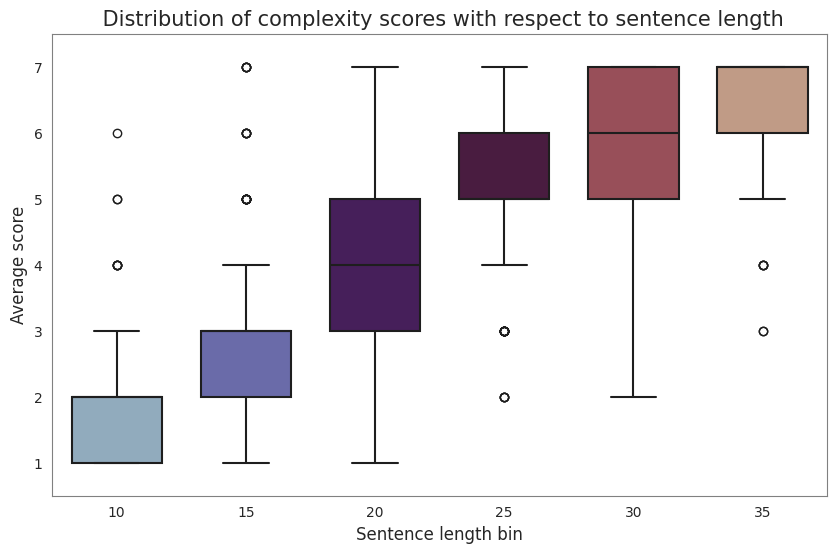

In [ ]:
# Считаем длину в словах
features_df['length'] = features_df['sentence'].apply(lambda x: len(x.split()))

def get_length_bin(length):
    return int(5 * round(float(length)/5))

features_df['length_bin'] = features_df['length'].apply(get_length_bin)

plot_df = features_df[features_df['length_bin'].between(10, 35)].copy()

plt.figure(figsize=(10, 6))
sns.set_style("white")

ax = sns.boxplot(
    x='length_bin',
    y='complexity',
    data=plot_df,
    palette="twilight",
    width=0.7,
    linewidth=1.5,
    showfliers=True
)

plt.xlabel('Sentence length bin', fontsize=12)
plt.ylabel('Average score', fontsize=12)
plt.title(' Distribution of complexity scores with respect to sentence length', fontsize=15)

for spine in ax.spines.values():
    spine.set_edgecolor('gray')
plt.ylim(0.5, 7.5)
plt.show()

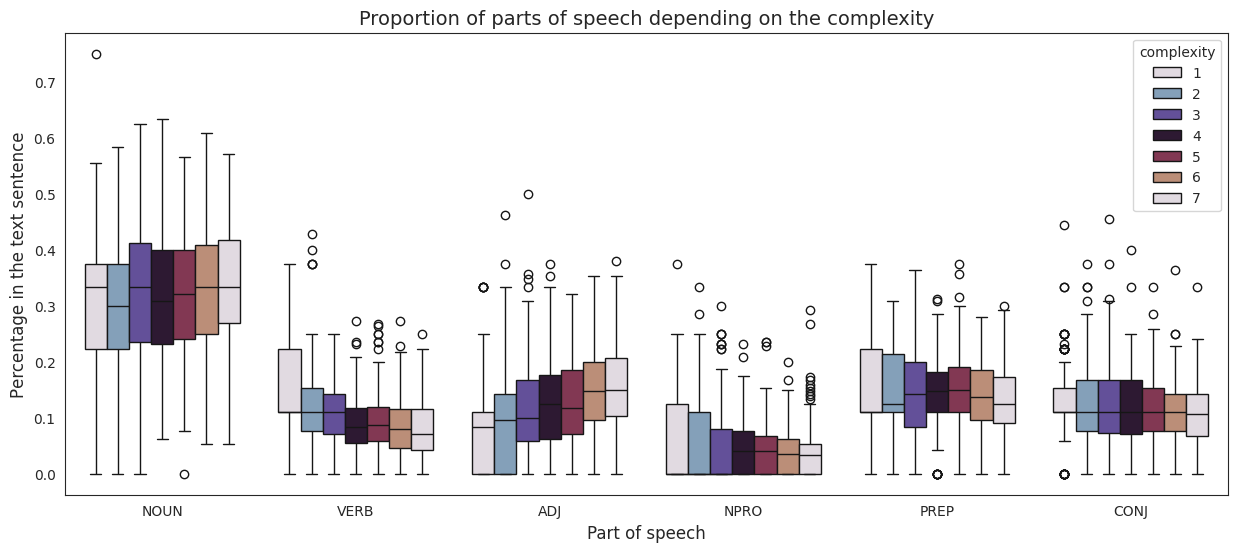

In [ ]:
def get_pos_stats(text):
    words = text.split()
    parsed = [morph.parse(w)[0].tag.POS for w in words if w.isalpha()]
    total = len(parsed) if len(parsed) > 0 else 1
    counts = Counter(parsed)
    return {
        'NOUN': counts['NOUN'] / total, # Существительные
        'VERB': (counts['VERB'] or 0 + counts['INFN'] or 0) / total, # Глаголы
        'ADJ': (counts['ADJF'] or 0 + counts['ADJS'] or 0) / total, # Прилагательные
        'NPRO': counts.get('NPRO', 0) / total,    # Местоимения
        'PREP': counts.get('PREP', 0) / total,    # Предлоги
        'CONJ': counts.get('CONJ', 0) / total,    # Союзы
    }

pos_stats = features_df['sentence'].apply(get_pos_stats).apply(pd.Series)
df_pos = pd.concat([features_df[['complexity']], pos_stats], axis=1)

df_melted = df_pos.melt(id_vars='complexity', var_name='POS', value_name='Ratio')

plt.figure(figsize=(15, 6))
sns.boxplot(x='POS', y='Ratio', hue='complexity', data=df_melted, palette='twilight')

plt.title('Proportion of parts of speech depending on the complexity', fontsize=14)
plt.xlabel('Part of speech', fontsize=12)
plt.ylabel('Рercentage in the text sentence', fontsize=12)
plt.show()

/tmp/ipython-input-3545078240.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


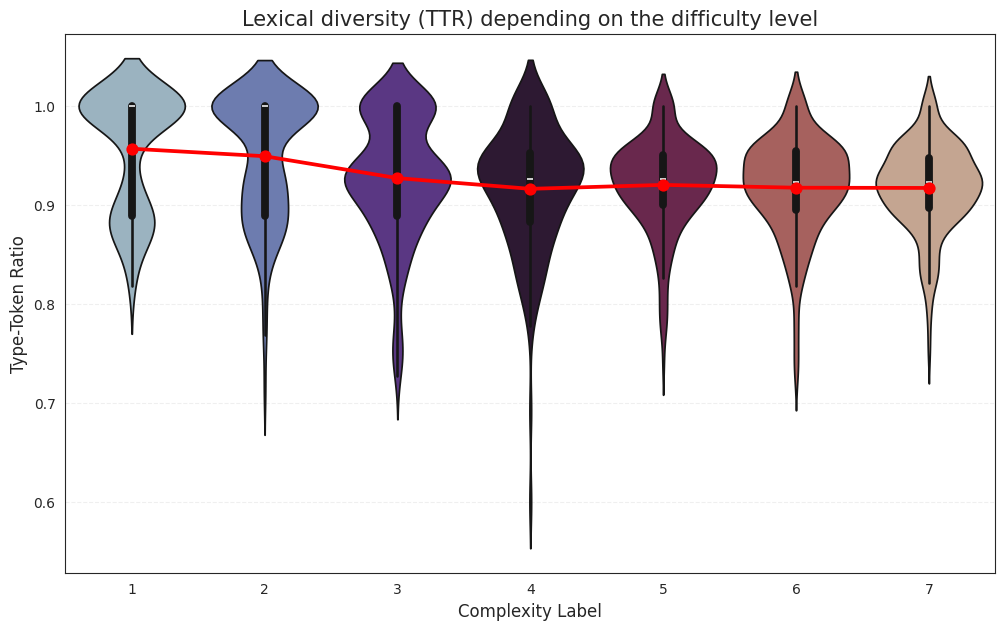

In [ ]:
import numpy as np

def calculate_ttr(text):
    words = [w.lower() for w in text.split() if w.isalpha()]
    if not words: return 0
    return len(set(words)) / len(words)

features_df['TTR'] = features_df['sentence'].apply(calculate_ttr)
features_df['complexity_int'] = features_df['complexity'].round().astype(int)

plt.figure(figsize=(12, 7))

sns.violinplot(
    x='complexity_int',
    y='TTR',
    data=features_df,
    palette='twilight'
)

plt.title('Lexical diversity (TTR) depending on the difficulty level', fontsize=15)
plt.xlabel('Complexity Label', fontsize=12)
plt.ylabel('Type-Token Ratio', fontsize=12)

sns.pointplot(x='complexity_int', y='TTR', data=features_df, estimator='mean', color='red', markers='o', linestyles='-', errorbar=None)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

Корреляция признаков со сложностью:
complexity                   1.000000
complexity_int               1.000000
length                       0.796496
length_bin                   0.796496
paper_sen_len                0.785384
                               ...   
synt_pronoun_ratio                NaN
synt_ellipsis_count               NaN
lex_rare_words_percentage         NaN
psych_surprisal_max               NaN
paper_Average_freq                NaN
Name: complexity, Length: 105, dtype: float64


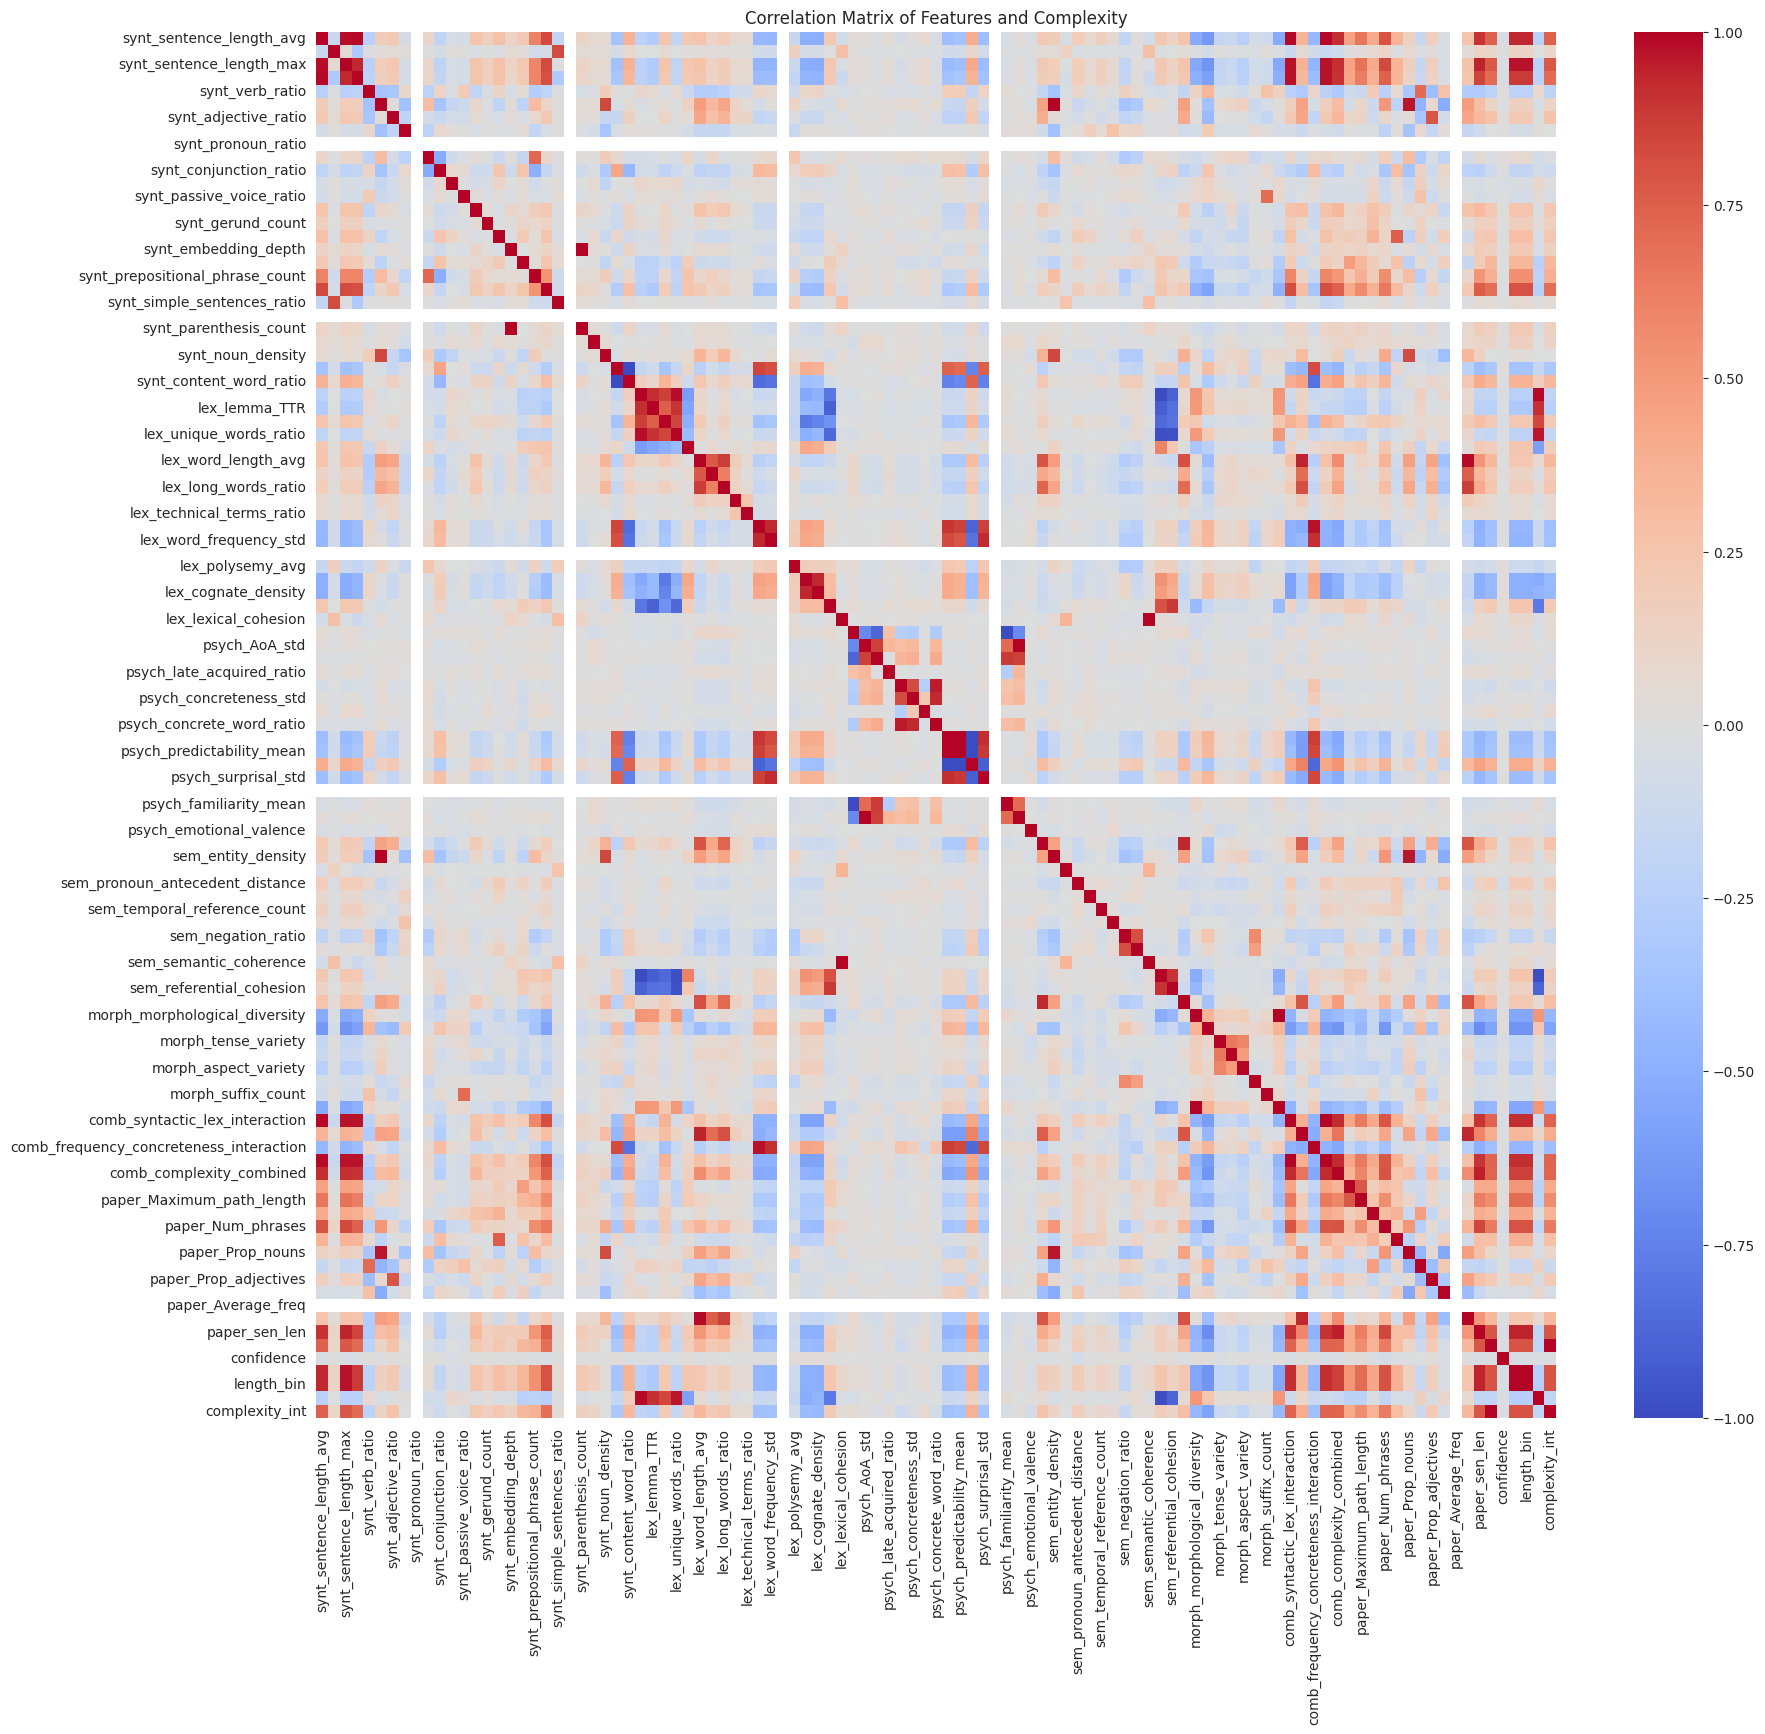

In [ ]:
# Исключаем нечисловые столбцы
features_df = features_df.drop(columns=['sentence'])

correlation_matrix = features_df.corr()
print("Корреляция признаков со сложностью:")
print(correlation_matrix['complexity'].sort_values(ascending=False))

plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features and Complexity')
plt.show()

In [ ]:
print("Корреляция признаков со сложностью:")
print(correlation_matrix['complexity'].sort_values(ascending=False))

Корреляция признаков со сложностью:
complexity                   1.000000
complexity_int               1.000000
length                       0.796496
length_bin                   0.796496
paper_sen_len                0.785384
                               ...   
synt_pronoun_ratio                NaN
synt_ellipsis_count               NaN
lex_rare_words_percentage         NaN
psych_surprisal_max               NaN
paper_Average_freq                NaN
Name: complexity, Length: 105, dtype: float64


In [ ]:
###????
features_df = features_df.drop(columns=['complexity_int'])

In [ ]:
X = features_df.drop(columns=["complexity", "sentence"], errors="ignore")

# выкинуть полностью пустые признаки
all_nan_cols = X.columns[X.isna().all()].tolist()
print("All-NaN columns:", all_nan_cols)

X = X.drop(columns=all_nan_cols)
X = X.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan)
y = features_df["complexity"].astype(float)

All-NaN columns: ['paper_Average_freq']


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Построение модели

## baseline (среднее арифметическое)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred_mean = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
y_pred_median = np.full_like(y_test, fill_value=np.median(y_train), dtype=float)

print("MAE baseline(mean):", mean_absolute_error(y_test, y_pred_mean))
print("MAE baseline(median):", mean_absolute_error(y_test, y_pred_median))

MAE baseline(mean): 1.6347222222222224
MAE baseline(median): 1.625


## Линейная регрессия, RandomForest и XGBoost

In [ ]:
# 1) Linear Regression
lin_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LinearRegression()),
])

# 2) RandomForest
rf_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor(
        n_estimators=600,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2
    )),
])

# 3) XGBoost
try:
    from xgboost import XGBRegressor

    xgb_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", XGBRegressor(
            n_estimators=1500,
            learning_rate=0.03,
            max_depth=6,
            subsample=0.9,
            colsample_bytree=0.8,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
        )),
    ])
except Exception as e:
    xgb_pipe = None
    print("XGBoost не доступен:", repr(e))

In [ ]:
pd.options.display.float_format = '{:.4f}'.format

def calculate_metrics(y_true, y_pred):
    """Вычисление полного набора метрик регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAPE": mean_absolute_percentage_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }

def eval_model_extended(name, pipe, X_train, y_train, X_test, y_test, cv):
    # 1. Cross-Validation
    cv_metrics = []
    for tr_idx, val_idx in tqdm(list(cv.split(X_train, y_train)), desc=f"{name} | CV"):
        model = clone(pipe)
        model.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        val_pred = np.clip(model.predict(X_train.iloc[val_idx]), 1.0, 7.0)
        cv_metrics.append(calculate_metrics(y_train.iloc[val_idx], val_pred))

    # Усреднение метрик по фолдам
    avg_cv = pd.DataFrame(cv_metrics).mean().add_prefix("cv_")

    # 2. Test Evaluation
    pipe.fit(X_train, y_train)
    test_pred = np.clip(pipe.predict(X_test), 1.0, 7.0)
    test_metrics = calculate_metrics(y_test, test_pred)
    test_res = {f"test_{k}": v for k, v in test_metrics.items()}

    return {"model": name, **avg_cv, **test_res}

# Запуск оценки
results = []
models = [("LinearRegression", lin_pipe), ("RandomForest", rf_pipe)]
if xgb_pipe: models.append(("XGBoost", xgb_pipe))

for name, pipe in models:
    results.append(eval_model_extended(name, pipe, X_train, y_train, X_test, y_test, cv))

res_df = pd.DataFrame(results).sort_values("test_MAE")
print(res_df.to_string())

LinearRegression | CV: 100%|██████████| 5/5 [00:01<00:00,  3.13it/s]
RandomForest | CV: 100%|██████████| 5/5 [01:12<00:00, 14.51s/it]
XGBoost | CV: 100%|██████████| 5/5 [01:00<00:00, 12.00s/it]


              model  cv_MAE  cv_MSE  cv_RMSE  cv_MAPE  cv_R2  test_MAE  test_MSE  test_RMSE  test_MAPE  test_R2
1      RandomForest  0.8689  1.2027   1.0955   0.2672 0.6716    0.8548    1.2038     1.0972     0.2514   0.6513
2           XGBoost  0.8833  1.2508   1.1173   0.2704 0.6584    0.8855    1.3113     1.1451     0.2589   0.6202
0  LinearRegression  0.8751  1.2288   1.1075   0.2651 0.6646    0.9191    1.4014     1.1838     0.2671   0.5941


In [ ]:
res_df

,model,cv_MAE,cv_MSE,cv_RMSE,cv_MAPE,cv_R2,test_MAE,test_MSE,test_RMSE,test_MAPE,test_R2
1,RandomForest,0.8689,1.2027,1.0955,0.2672,0.6716,0.8548,1.2038,1.0972,0.2514,0.6513
2,XGBoost,0.8833,1.2508,1.1173,0.2704,0.6584,0.8855,1.3113,1.1451,0.2589,0.6202
0,LinearRegression,0.8751,1.2288,1.1075,0.2651,0.6646,0.9191,1.4014,1.1838,0.2671,0.5941


In [ ]:
@contextmanager
def tqdm_joblib(tqdm_object):
    """Progress bar для joblib.Parallel (работает с n_jobs=-1)."""
    class TqdmBatchCompletionCallback(parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_cb = parallel.BatchCompletionCallBack
    parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        parallel.BatchCompletionCallBack = old_cb
        tqdm_object.close()

### RandomForest

In [ ]:
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

def clip_1_7(pred):
    return np.clip(pred, 1.0, 7.0)

rf_param_dist = {
    "model__max_depth": [None] + list(range(4, 31)),
    "model__max_features": ["sqrt", "log2", 0.3, 0.5, 0.8, 1.0],
    "model__min_samples_leaf": randint(1, 9),
    "model__min_samples_split": randint(2, 21),
    "model__bootstrap": [True, False],
}

rf_n_iter = 20
rf_total_fits = rf_n_iter * cv.get_n_splits(X_train, y_train)

rf_search = RandomizedSearchCV(
    rf_pipe,
    param_distributions=rf_param_dist,
    n_iter=rf_n_iter,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=0,
)

with tqdm_joblib(tqdm(total=rf_total_fits, desc="RF RandomizedSearch (fits)")):
    rf_search.fit(X_train, y_train)

best_rf = rf_search.best_estimator_
pred = clip_1_7(best_rf.predict(X_test))
print("RF best params:", rf_search.best_params_)
print("RF test MAE:", mean_absolute_error(y_test, pred))

RF RandomizedSearch (fits): 700it [14:06,  1.21s/it]


RF best params: {'model__bootstrap': True, 'model__max_depth': 22, 'model__max_features': 0.8, 'model__min_samples_leaf': 7, 'model__min_samples_split': 12}
RF test MAE: 0.8618116027979783


In [ ]:
pred_tuned = clip_1_7(best_rf.predict(X_test))

# Вычисление полного набора метрик для Tuned RF
tuned_metrics = calculate_metrics(y_test, pred_tuned)

print("\n--- Optimized Random Forest Metrics ---")
for metric, value in tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

# Сравнение с базовой моделью
base_rf_mae = res_df.loc[res_df['model'] == 'RandomForest', 'test_MAE'].values[0]
print(f"\nImprovement in MAE: {base_rf_mae - tuned_metrics['MAE']:.4f}")


--- Optimized Random Forest Metrics ---
MAE: 0.8618
MSE: 1.2192
RMSE: 1.1042
MAPE: 0.2541
R2: 0.6469

Improvement in MAE: -0.0070


--- Random Forest Feature Importance (Top 10) ---
                               feature  importance
                         paper_sen_len      0.4029
                            length_bin      0.1824
                                length      0.1592
              synt_sentence_length_max      0.0273
                     synt_adverb_ratio      0.0113
              comb_complexity_combined      0.0103
                synt_preposition_ratio      0.0099
                   lex_word_length_std      0.0096
              synt_punctuation_density      0.0086
comb_surprisal_word_length_interaction      0.0078


/tmp/ipython-input-2636926063.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


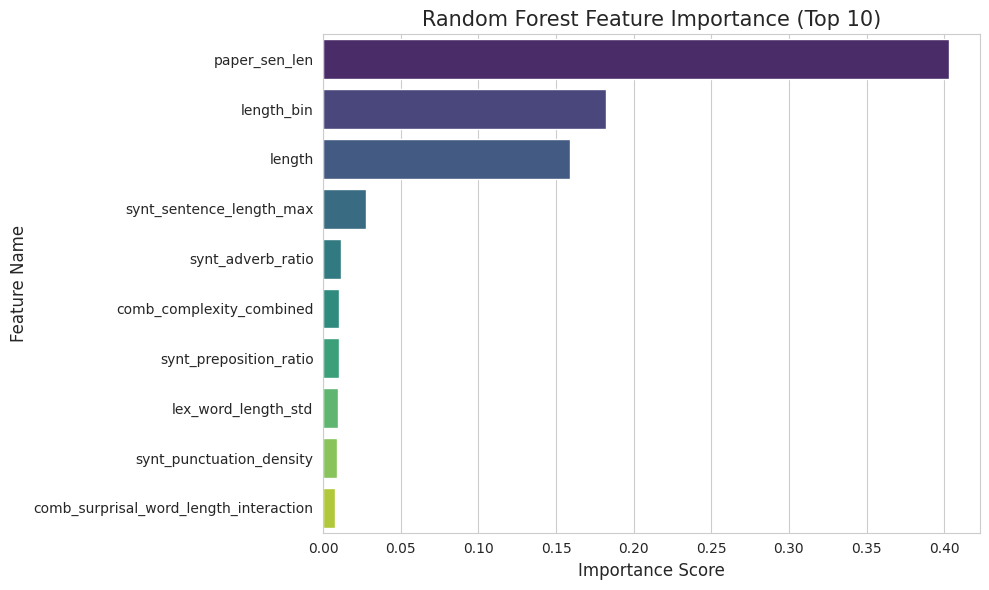

In [ ]:
rf_model = best_rf.named_steps['model']

# Получаем важность признаков
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Создаем DataFrame
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Вывод текстом топ-10
print("--- Random Forest Feature Importance (Top 10) ---")
print(fi_df.head(10).to_string(index=False))

# Визуализация
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.barplot(
    data=fi_df.head(10),
    x='importance',
    y='feature',
    palette='viridis'
)
plt.title('Random Forest Feature Importance (Top 10)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()

### XGBoost

In [ ]:
# 1. Сетка параметров для XGBoost
xgb_param_dist = {
    "model__n_estimators": randint(500, 3000),       # Больше деревьев
    "model__learning_rate": uniform(0.005, 0.1),     # От очень медленного до быстрого
    "model__max_depth": randint(3, 10),              # Глубина
    "model__subsample": uniform(0.6, 0.4),           # Доля выборки для каждого дерева (0.6-1.0)
    "model__colsample_bytree": uniform(0.6, 0.4),    # Доля признаков для каждого дерева
    "model__reg_alpha": uniform(0, 5),               # L1 регуляризация
    "model__reg_lambda": uniform(1, 5),              # L2 регуляризация
    "model__gamma": uniform(0, 1.0)                  # Минимальное снижение loss для разделения
}

# 2. Настройка RandomizedSearchCV
xgb_n_iter = 10
xgb_search = RandomizedSearchCV(
    xgb_pipe,
    param_distributions=xgb_param_dist,
    n_iter=xgb_n_iter,
    scoring="neg_mean_absolute_error",
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print("Starting XGBoost tuning...")
xgb_search.fit(X_train, y_train)

# 3. Лучшая модель и предсказания
best_xgb = xgb_search.best_estimator_
pred_xgb_tuned = clip_1_7(best_xgb.predict(X_test))

# 4. Вывод метрик
xgb_tuned_metrics = calculate_metrics(y_test, pred_xgb_tuned)

print("\n--- Optimized XGBoost Metrics ---")
for metric, value in xgb_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nBest XGB Params:", xgb_search.best_params_)

Starting XGBoost tuning...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

--- Optimized XGBoost Metrics ---
MAE: 0.9057
MSE: 1.3262
RMSE: 1.1516
MAPE: 0.2657
R2: 0.6159

Best XGB Params: {'model__colsample_bytree': np.float64(0.9439761626945282), 'model__gamma': np.float64(0.6803075385877797), 'model__learning_rate': np.float64(0.0500499251969543), 'model__max_depth': 4, 'model__n_estimators': 2935, 'model__reg_alpha': np.float64(4.711008778424263), 'model__reg_lambda': np.float64(3.8164410892276965), 'model__subsample': np.float64(0.7541666010159664)}


### CatBoost c optuna

In [ ]:
import optuna
from sklearn.model_selection import KFold
from sklearn.impute import SimpleImputer
from catboost import CatBoostRegressor

def objective_catboost_fast(trial):
    params = {
        "iterations": 1000,
        "depth": trial.suggest_int("depth", 4, 7),
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.3, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1e-1, 10.0, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 50),
        "random_state": 42,
        "verbose": 0,
        "loss_function": "MAE",
        "allow_writing_files": False
    }

    kf = KFold(n_splits=3, shuffle=True, random_state=42)
    mae_scores = []

    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        imp = SimpleImputer(strategy="median")
        X_tr_imp = imp.fit_transform(X_tr)
        X_val_imp = imp.transform(X_val)

        model = CatBoostRegressor(**params)

        model.fit(
            X_tr_imp, y_tr,
            eval_set=(X_val_imp, y_val),
            early_stopping_rounds=50,
            verbose=False
        )

        preds = np.clip(model.predict(X_val_imp), 1, 7)
        mae_scores.append(mean_absolute_error(y_val, preds))

    return np.mean(mae_scores)

study_cb = optuna.create_study(direction="minimize")
study_cb.optimize(objective_catboost_fast, n_trials=30, show_progress_bar=True)

print("Best Value:", study_cb.best_value)

[I 2026-01-11 17:34:53,094] A new study created in memory with name: no-name-dfa46da4-7033-41be-9c7d-ca19f458f059


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-11 17:34:55,800] Trial 0 finished with value: 0.856381963491601 and parameters: {'depth': 4, 'learning_rate': 0.050333709649409954, 'l2_leaf_reg': 3.5057672228489487, 'subsample': 0.6679933446054575, 'colsample_bylevel': 0.6473739471384673, 'min_data_in_leaf': 9}. Best is trial 0 with value: 0.856381963491601.
[I 2026-01-11 17:35:01,637] Trial 1 finished with value: 0.8552341755110092 and parameters: {'depth': 5, 'learning_rate': 0.023762106518152096, 'l2_leaf_reg': 1.0552684986625642, 'subsample': 0.9601391813983162, 'colsample_bylevel': 0.8776713516079495, 'min_data_in_leaf': 19}. Best is trial 1 with value: 0.8552341755110092.
[I 2026-01-11 17:35:15,907] Trial 2 finished with value: 0.8582945893240255 and parameters: {'depth': 7, 'learning_rate': 0.022965991589224872, 'l2_leaf_reg': 0.11943504288170136, 'subsample': 0.7437671710076408, 'colsample_bylevel': 0.8112524902741595, 'min_data_in_leaf': 14}. Best is trial 1 with value: 0.8552341755110092.
[I 2026-01-11 17:35:34,8

In [ ]:
print("Best CatBoost Params:", study_cb.best_params)
print("Best CV MAE:", study_cb.best_value)

Best CatBoost Params: {'depth': 5, 'learning_rate': 0.018485028469261377, 'l2_leaf_reg': 1.676630317879439, 'subsample': 0.9618180430388977, 'colsample_bylevel': 0.8800230033723098, 'min_data_in_leaf': 17}
Best CV MAE: 0.8486660949609438


In [ ]:
# Получаем лучшие параметры из Optuna
best_params = study_cb.best_params

# Создаем финальную модель
final_cb = CatBoostRegressor(
    **best_params,
    loss_function="MAE",
    verbose=0,
    allow_writing_files=False,
    random_state=42
)

# Полный Pipeline
final_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", final_cb)
])

# Обучаем на всем train
final_pipe.fit(X_train, y_train)

# Предсказываем на отложенном test
pred_cb = clip_1_7(final_pipe.predict(X_test))

In [ ]:
# Вывод метрик
CatBoost_tuned_metrics = calculate_metrics(y_test, pred_cb)

print("\n--- Optimized CatBoost Metrics ---")
for metric, value in CatBoost_tuned_metrics.items():
    print(f"{metric}: {value:.4f}")

print("\nBest CatBoost Params:", xgb_search.best_params_)


--- Optimized CatBoost Metrics ---
MAE: 0.8830
MSE: 1.2915
RMSE: 1.1365
MAPE: 0.2560
R2: 0.6259

Best CatBoost Params: {'model__colsample_bytree': np.float64(0.9439761626945282), 'model__gamma': np.float64(0.6803075385877797), 'model__learning_rate': np.float64(0.0500499251969543), 'model__max_depth': 4, 'model__n_estimators': 2935, 'model__reg_alpha': np.float64(4.711008778424263), 'model__reg_lambda': np.float64(3.8164410892276965), 'model__subsample': np.float64(0.7541666010159664)}


--- Top 10 Most Important Features ---
                     feature  importance
                      length     14.0589
               paper_sen_len     13.4279
                  length_bin     10.6213
    synt_sentence_length_max      5.0759
    synt_punctuation_density      2.9026
synt_complex_sentences_ratio      2.4230
      synt_preposition_ratio      2.2767
    synt_sentence_length_avg      2.1866
    synt_sentence_length_min      1.9949
         lex_word_length_std      1.6713


/tmp/ipython-input-3792874523.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


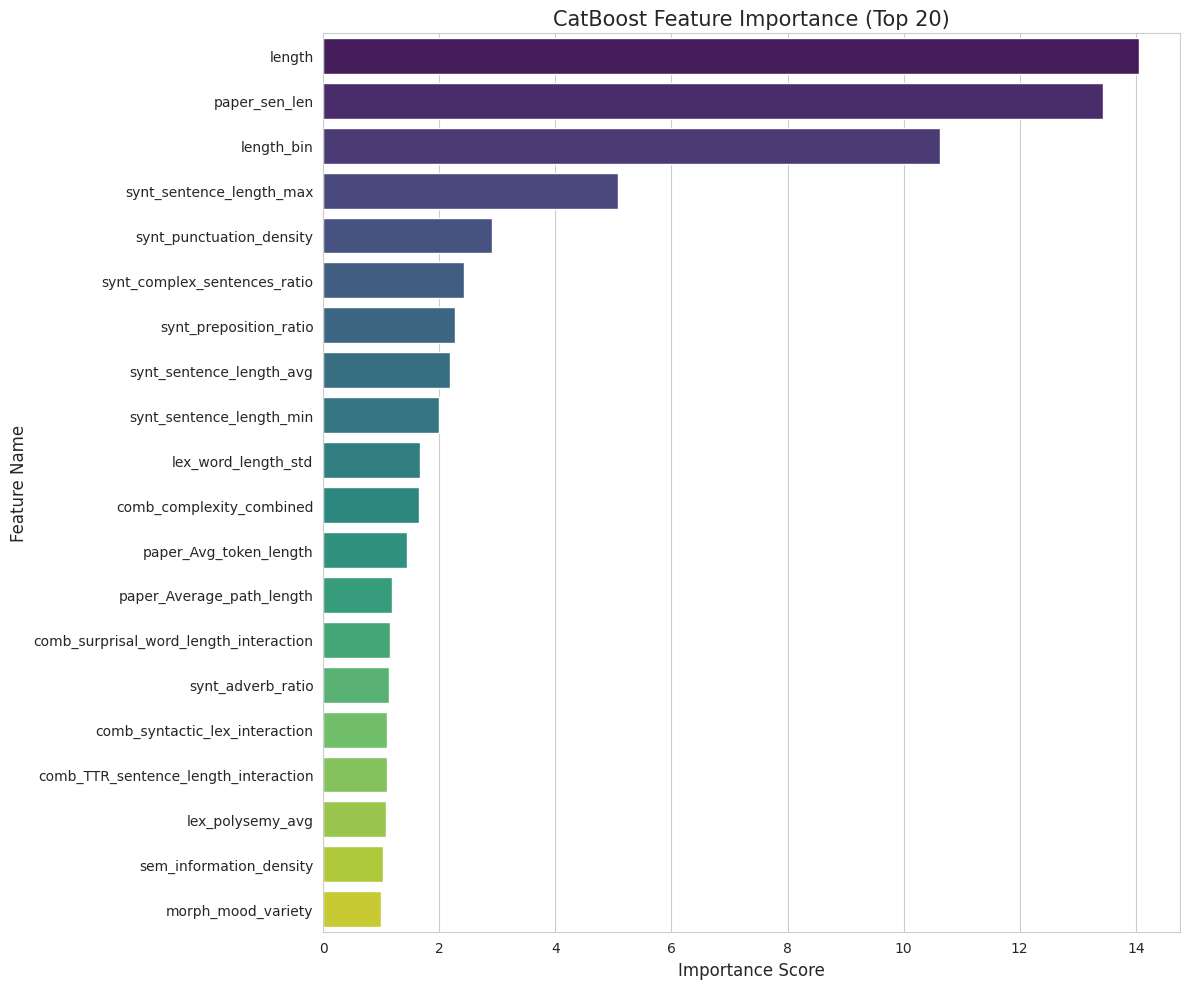

In [ ]:
feature_importances = final_cb.get_feature_importance()
feature_names = X_train.columns

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
}).sort_values(by='importance', ascending=False)

print("--- Top 10 Most Important Features ---")
print(fi_df.head(10).to_string(index=False))

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

sns.barplot(
    data=fi_df.head(20),
    x='importance',
    y='feature',
    palette='viridis'
)

plt.title('CatBoost Feature Importance (Top 20)', fontsize=15)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature Name', fontsize=12)
plt.tight_layout()
plt.show()